In [66]:
#imports
import sys
sys.path.append("../../src")
# A collection of handy imports. Not that important.
from common_imports import * 
import numerical_quenches as nq
from numerical_quenches import g_linear_hold

#These imports will be used to calculate projectors
import kibble_zurek as kz
import time_evolved_z_correlators as zz



In [ ]:
#Define Sudden quench protocol
def g_sudden_quench(t,args):
    g0,gf,t0 = args
    if t<t0:
        return g0
    else:
        return gf

#Critical Times of DQPTs
def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns
def est_z_defects(tau,n):
    numerator = n*n+n
    denom = 2**(n-1)*4*pi*sqrt(2*tau)
    return numerator/denom

def est_x_defects(tau,n):
    numerator = n-1
    denom = 4*pi*sqrt(2*tau)

    return numerator/denom


In [67]:
t0=critical_times(0,1)
#tcs = critical_times(0,10)
#check_times = np.linspace(.001,4*t0,40)
t0

array([0.78539816])

In [60]:
tau = 1
L = 100
#Time Evaluation interval
t_eval0 = np.linspace(-tau, tau-tau/2, 100,endpoint=False)
t_evals = [np.concatenate((t_eval0,np.linspace(tau,tau+t0,25))) for t0 in check_times]


for t in t_evals:
    print(t[-24]-1/8)

0.8750416666666667
0.8783970006982798
0.8817523347298928
0.8851076687615058
0.8884630027931189
0.8918183368247319
0.8951736708563449
0.898529004887958
0.901884338919571
0.905239672951184
0.908595006982797
0.9119503410144099
0.9153056750460229
0.9186610090776359
0.922016343109249
0.925371677140862
0.928727011172475
0.9320823452040881
0.9354376792357011
0.9387930132673141
0.9421483472989272
0.9455036813305402
0.9488590153621532
0.9522143493937663
0.9555696834253793
0.9589250174569923
0.9622803514886054
0.9656356855202184
0.9689910195518314
0.9723463535834445
0.9757016876150575
0.9790570216466705
0.9824123556782836
0.9857676897098966
0.9891230237415096
0.9924783577731227
0.9958336918047357
0.9991890258363487
1.0025443598679618
1.0058996938995748


In [61]:
slow_args = [tau,t_eval0[-1]]
g0 = g_linear_hold(t_eval0[0],slow_args)
gf = g_linear_hold(tau,slow_args)
print(gf)
sudden_args=[g0,gf,tau]
    
slow_states_tc=[]
sudden_states_tc=[]
for t_eval in tqdm(t_evals):
    slow_states = nq.states(L,t_eval,g_linear_hold,slow_args)
    sudden_states= nq.states(L,t_eval,g_sudden_quench,sudden_args)
    slow_states_tc.append(slow_states)
    sudden_states_tc.append(sudden_states_tc)

0.5150000000000001


  5%|▌         | 2/40 [00:00<00:03, 10.74it/s]

2.0
2.0
2.0
2.0
2.0


 10%|█         | 4/40 [00:00<00:03, 11.01it/s]

2.0
2.0
2.0
2.0
2.0


...

2.0
2.0
2.0


 95%|█████████▌| 38/40 [00:04<00:00,  7.51it/s]

2.0
2.0
2.0
2.0


100%|██████████| 40/40 [00:04<00:00,  8.61it/s]

2.0
2.0


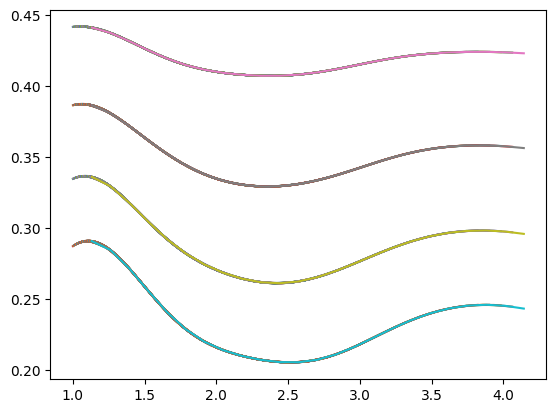

In [62]:
ns = [2,3,4,5]
avgs_tau=[]
for states,t_eval,tc in zip(slow_states_tc,t_evals,check_times):
    P = [array([kz.P_n(ni,s) for s in states] )for ni in ns]
    avgs = []
    for p in P:
        avgs.append(np.average(p[t_eval>tau]))
        plot(t_eval[t_eval>tau],p[t_eval>tau],label=tc)
  #      plt.hlines(np.average(p[t_eval>tau]),tau,t_eval[-1])
    avgs_tau.append(avgs)
   # show()
    

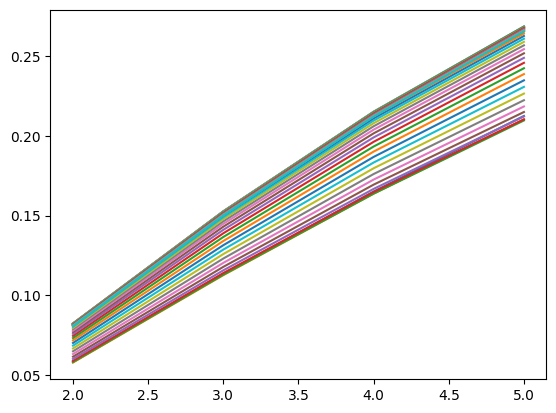

In [63]:
full_defects=[]
for avgs,tc in zip(avgs_tau,check_times):
    defects= [abs(1/2- a) for ni,a in zip(ns,avgs)]
    full_defects.append(defects)
    plot(ns,defects,label=tc/t0)
show()


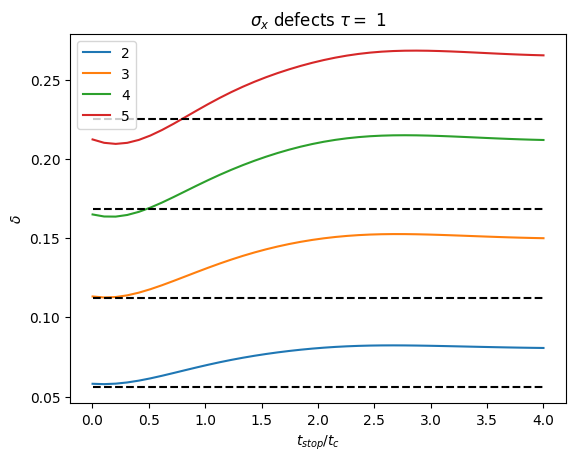

In [64]:
full_defects=array(full_defects)
for fd,n in zip(full_defects.T,ns):
    plot(check_times/t0,fd,label=n)
    plt.hlines(est_x_defects(tau,n),check_times[0]/t0,check_times[-1]/t0,color="black",ls="--")


title(rf"$\sigma_x$ defects $\tau=$ {tau}")
xlabel(r"$t_{stop}/t_c$")
ylabel(r"$\delta$")
legend()

Text(0, 0.5, '$t/t_c$')

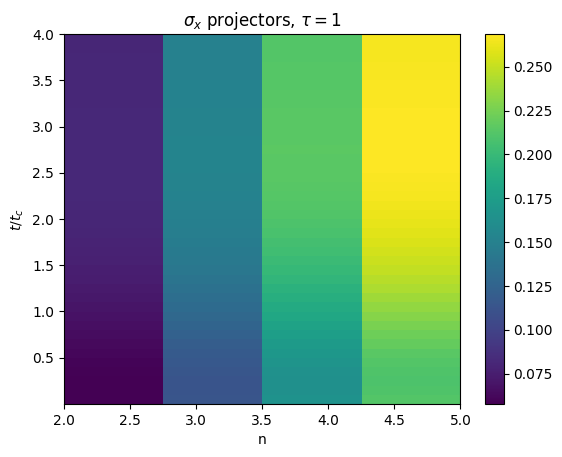

In [65]:
imshow(full_defects,aspect="auto",extent=[ns[0],ns[-1],check_times[0]/t0,check_times[-1]/t0],origin='lower')
xlabel("n")
title(rf"$\sigma_x$ projectors, $\tau ={tau}$")
plt.colorbar()
ylabel(r"$t/t_c$")